In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr

import confidence_intervals

In [3]:
cattaneo_data = pd.read_stata('data/cattaneo2.dta')
pd.set_option('display.max_columns', None)

In [4]:
cattaneo_smoker = cattaneo_data[cattaneo_data['mbsmoke'] == 'smoker']
cattaneo_non_smoker = cattaneo_data[cattaneo_data['mbsmoke'] == 'nonsmoker']

In [5]:
smoker_bweight = []
for index, row in cattaneo_smoker.iterrows():
  smoker_bweight.append(row['bweight'])
print(np.std(smoker_bweight))

non_smoker_bweight = []
for index, row in cattaneo_non_smoker.iterrows():
  non_smoker_bweight.append(row['bweight'])
print(np.std(non_smoker_bweight))

smoker_bweight_missing = np.append(smoker_bweight, np.ones(len(non_smoker_bweight)) * np.nan)
non_smoker_bweight_missing = np.append(non_smoker_bweight, np.ones(len(smoker_bweight)) * np.nan)

560.5683664552373
570.6115756518803


In [18]:
print("Sub-Gaussian intervals with sub-Gaussian constant 100")
print("Sub-Gaussian average earning winner: {}".format(confidence_intervals.adaptive_CI_subG(smoker_bweight_missing, 0.05, 100)))
print("Sub-Gaussian average earning control: {}".format(confidence_intervals.adaptive_CI_subG(non_smoker_bweight_missing, 0.05, 100)))

print("Symmetric interval average earning winner: {}".format(confidence_intervals.adaptive_TS(smoker_bweight_missing, 0.05)))
print("Symmetric interval average earning control: {}".format(confidence_intervals.adaptive_TS(non_smoker_bweight_missing, 0.05)))

print("Gaussian interval average earning winner: {}".format(confidence_intervals.adaptive_CI_Gaussian(smoker_bweight_missing, 0.05, 560.6)))
print("Gaussian interval average earning control: {}".format(confidence_intervals.adaptive_CI_Gaussian(non_smoker_bweight_missing, 0.05, 570.6)))


Sub-Gaussian intervals with sub-Gaussian constant 100
Sub-Gaussian average earning winner: {'left': 2979.7087566740906, 'right': 3295.6106877703537}
Sub-Gaussian average earning control: {'left': 3356.224151846835, 'right': 3469.599035024525}
Symmetric interval average earning winner: {'left': 397.0, 'right': 5018.0}
Symmetric interval average earning control: {'left': 3260.0, 'right': 3629.0}
Gaussian interval average earning winner: {'left': 2404.5126998033884, 'right': 3917.4873001966116}
Gaussian interval average earning control: {'left': 3268.280684998125, 'right': 3592.719315001875}


(array([  5.,   6.,   5.,  25., 113., 266., 305., 115.,  21.,   3.]),
 array([ 397. ,  859.1, 1321.2, 1783.3, 2245.4, 2707.5, 3169.6, 3631.7,
        4093.8, 4555.9, 5018. ]),
 <BarContainer object of 10 artists>)

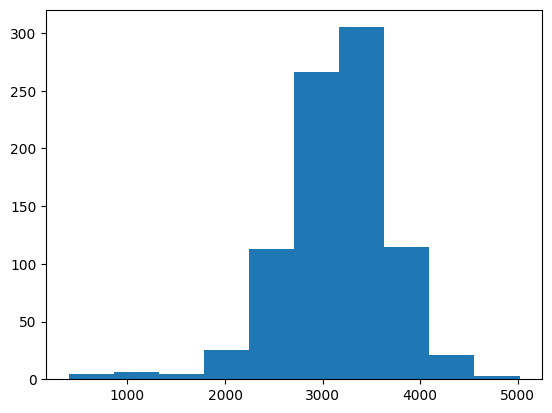

In [15]:
plt.hist(smoker_bweight)

(array([  15.,   17.,   23.,   90.,  427., 1322., 1331.,  468.,   81.,
           4.]),
 array([ 340.,  856., 1372., 1888., 2404., 2920., 3436., 3952., 4468.,
        4984., 5500.]),
 <BarContainer object of 10 artists>)

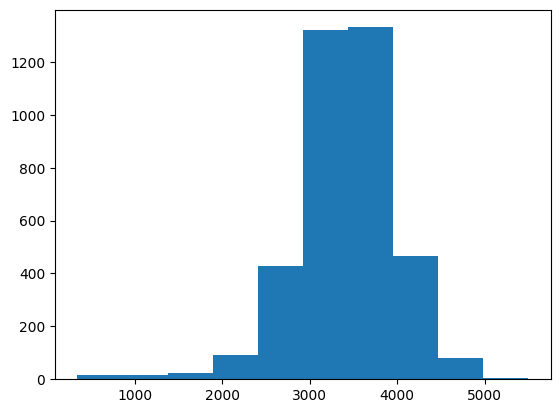

In [9]:
plt.hist(non_smoker_bweight)